# Step 4 Evaluation — GPT-4o (t = 0)

Computes the paper's Step 4 metrics (Eq. 5–6):

- **Positive-F1** — the mean per-cell factor-set F1 over cells whose gold annotation contains at
  least one factor (`D_positive`);
- **None-accuracy** — how often the model correctly predicts *no factor* on empty gold cells.

Both are computed for Preferences, Constraints, and their union — the **Integrated** table, whose
`F1_Pos_Int` values back the Interpretation-Table row of paper Table 7.

**Requires the raw outputs** (`results/gpt4o/raw/`, git-ignored) for the predictions and the Step-1 scope;
the shipped `Step4_*_Score.csv` files were produced from them. The second cell draws the
per-conversation distribution plots.

## Scoring — Positive-F1 and None-accuracy (Preferences / Constraints / Integrated)

In [1]:
import os
import json
import pandas as pd
from typing import List, Dict, Tuple, Set

# ─────────────────────────────────────────────────────────────
# 0) User settings
# ─────────────────────────────────────────────────────────────
results_dir = "results/gpt4o/raw"      # Step4 prediction results folder
gold_dir    = "data/gold"   # Gold answer folder
techniques  = ["CoT", "PD", "SR", "MoRE"]
iterations  = range(1, 6)

# ─────────────────────────────────────────────────────────────
# 1) Preprocessing and utility functions
# ─────────────────────────────────────────────────────────────
def normalize_name(name: str) -> str:
    """Restaurant name normalization (simple)."""
    return name.lower().strip()

def parse_factors(factor_str: str) -> Set[str]:
    """'A1,A2' → {'A1','A2'} / 'None'→ set()"""
    if not factor_str or factor_str.strip().lower() == "none":
        return set()
    return {f.strip() for f in factor_str.split(",") if f.strip()}

def positive_f1(gold_set: Set[str], pred_set: Set[str]) -> float:
    """F1 for cells where gold is not None."""
    inter = len(gold_set & pred_set)
    precision = inter / len(pred_set) if pred_set else 0.0
    recall    = inter / len(gold_set) if gold_set else 0.0
    return 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

def evaluate_tables(gold_table: List[Dict], pred_table: List[Dict],
                    factor_col: str) -> Tuple[float, float]:
    """
    Both tables are already filtered to the (participant, restaurant) scope.
    Returns: (mean Positive F1, mean None Accuracy)
    """
    gold = {(it["participant"], normalize_name(it["restaurant"])):
            parse_factors(it[factor_col]) for it in gold_table}
    pred = {(it["participant"], normalize_name(it["restaurant"])):
            parse_factors(it[factor_col]) for it in pred_table}

    pos_sum = pos_cnt = 0
    none_sum = none_cnt = 0

    for key, gold_set in gold.items():
        pred_set = pred.get(key, set())

        if gold_set:                                   # positive cell
            pos_sum += positive_f1(gold_set, pred_set)
            pos_cnt += 1
        else:                                          # gold == None cell
            none_sum += 1.0 if not pred_set else 0.0
            none_cnt += 1

    pos_mean  = pos_sum  / pos_cnt  if pos_cnt  else 0.0
    none_mean = none_sum / none_cnt if none_cnt else 1.0
    return pos_mean, none_mean

# ─────────────────────────────────────────────────────────────
# 1-B) preferences + constraints → integrated
# ─────────────────────────────────────────────────────────────
def integrate_tables(pref_tbl: List[Dict], cons_tbl: List[Dict],
                     pref_col: str = "preferences",
                     cons_col: str = "constraints") -> List[Dict]:
    """
    Build the union of preferences and constraints per (participant, restaurant),
    and returns it as a new 'integrated' column.
    """
    union_map: Dict[Tuple[str, str], Set[str]] = {}

    # Preferences
    for row in pref_tbl:
        key = (row["participant"], normalize_name(row["restaurant"]))
        union_map.setdefault(key, set()).update(parse_factors(row[pref_col]))

    # Constraints
    for row in cons_tbl:
        key = (row["participant"], normalize_name(row["restaurant"]))
        union_map.setdefault(key, set()).update(parse_factors(row[cons_col]))

    # dict → list[dict]
    integrated_list = []
    for (participant, restaurant), factors in union_map.items():
        integrated_list.append({
            "participant": participant,
            "restaurant": restaurant,
            "integrated": ",".join(sorted(factors)) if factors else "None"
        })
    return integrated_list

# ─────────────────────────────────────────────────────────────
# 2) Evaluate all Step4 conversations, techniques, and iterations
# ─────────────────────────────────────────────────────────────
pref_scores, cons_scores, int_scores = [], [], []

for folder in os.listdir(results_dir):
    if not folder.endswith("_log"):
        continue
    conv_id     = folder.replace("_log", "")
    folder_path = os.path.join(results_dir, folder)

    # ── 2-1) Obtain the evaluation scope ───────────────────
    with open(os.path.join(folder_path, f"{folder}_final_results.json"),
              encoding="utf-8") as f:
        final_json = json.load(f)
    scope_participants = set(final_json["step1"]["participants"])
    scope_restaurants  = {normalize_name(r)
                          for r in final_json["step1"]["restaurant_brands"]}

    # ── 2-2) Load Gold and filter by scope ─────────────────
    with open(os.path.join(gold_dir, f"{conv_id}_log/step4_gold.json"),
              encoding="utf-8") as f:
        gold4 = json.load(f)

    gold_pref = [g for g in gold4["preference_table"]
                 if g["participant"] in scope_participants
                 and normalize_name(g["restaurant"]) in scope_restaurants]
    gold_cons = [g for g in gold4["constraint_table"]
                 if g["participant"] in scope_participants
                 and normalize_name(g["restaurant"]) in scope_restaurants]

    # ── 2-3) Technique x iteration evaluation ──────────────
    for tech in techniques:
        for it in iterations:
            pred_path = os.path.join(folder_path,
                                     f"{conv_id}_log_Step4_{tech}_{it}.json")
            if not os.path.isfile(pred_path):
                continue
            with open(pred_path, encoding="utf-8") as f:
                result4 = json.load(f)["Result"]

            # Prediction-scope filter
            pred_pref = [p for p in result4["preference_table"]
                         if p["participant"] in scope_participants
                         and normalize_name(p["restaurant"]) in scope_restaurants]
            pred_cons = [p for p in result4["constraint_table"]
                         if p["participant"] in scope_participants
                         and normalize_name(p["restaurant"]) in scope_restaurants]

            # ── (1) Preferences
            f1_pos_pref, acc_none_pref = evaluate_tables(
                gold_pref, pred_pref, factor_col="preferences"
            )
            pref_scores.append({
                "conversation_id": conv_id,
                "technique":       tech,
                "F1_Pos_Pref":     f1_pos_pref,
                "Acc_None_Pref":   acc_none_pref
            })

            # ── (2) Constraints
            f1_pos_cons, acc_none_cons = evaluate_tables(
                gold_cons, pred_cons, factor_col="constraints"
            )
            cons_scores.append({
                "conversation_id": conv_id,
                "technique":       tech,
                "F1_Pos_Cons":     f1_pos_cons,
                "Acc_None_Cons":   acc_none_cons
            })

            # ── (3) Integrated
            gold_int = integrate_tables(gold_pref, gold_cons)
            pred_int = integrate_tables(pred_pref, pred_cons)
            f1_pos_int, acc_none_int = evaluate_tables(
                gold_int, pred_int, factor_col="integrated"
            )
            int_scores.append({
                "conversation_id": conv_id,
                "technique":       tech,
                "F1_Pos_Int":      f1_pos_int,
                "Acc_None_Int":    acc_none_int
            })

# ─────────────────────────────────────────────────────────────
# 3) Average over iterations -> write CSV
# ─────────────────────────────────────────────────────────────
def build_metric_rows(df_mean: pd.DataFrame, metric_col: str) -> List[Dict]:
    """Convert pivot results into per-Metric row form."""
    rows = []
    pivot = df_mean.pivot(index="conversation_id",
                          columns="technique", values=metric_col)
    avg = pivot.mean()
    std = pivot.std()

    # Individual conversation
    for conv in pivot.index:
        row = {"Metric": metric_col, "conversation_id": conv}
        for tech in techniques:
            row[tech] = pivot.loc[conv, tech]
        rows.append(row)

    # Average / Std
    rows.append({"Metric": metric_col, "conversation_id": "Average",
                 **{tech: avg[tech] for tech in techniques}})
    rows.append({"Metric": metric_col, "conversation_id": "Std",
                 **{tech: std[tech] for tech in techniques}})
    return rows

def save_scores(scores: List[Dict], metrics: List[str],
                filename: str, metric_prefix: str):
    df = pd.DataFrame(scores)
    df_mean = (
        df.groupby(["conversation_id", "technique"])[metrics]
          .mean()
          .reset_index()
    )
    rows = []
    for metric in metrics:
        rows += build_metric_rows(df_mean, metric)
    pd.DataFrame(rows,
                 columns=["Metric", "conversation_id"] + techniques
                ).to_csv(filename, index=False, encoding="utf-8-sig")

# Preferences CSV
save_scores(pref_scores,
            ["F1_Pos_Pref", "Acc_None_Pref"],
            "results/gpt4o/Step4_Preferences_Score.csv", "Pref")

# Constraints CSV
save_scores(cons_scores,
            ["F1_Pos_Cons", "Acc_None_Cons"],
            "results/gpt4o/Step4_Constraints_Score.csv", "Cons")

# Integrated CSV
save_scores(int_scores,
            ["F1_Pos_Int", "Acc_None_Int"],
            "results/gpt4o/Step4_Integrated_Score.csv", "Int")

print("✅  Step4_Preferences_Score.csv / Step4_Constraints_Score.csv / Step4_Integrated_Score.csv created")


✅  Step4_Preferences_Score.csv / Step4_Constraints_Score.csv / Step4_Integrated_Score.csv 생성 완료


## Plots — per-conversation distributions per technique

✅ Saved _temp0.0/Step4_F1_Pos_Pref_plot.png


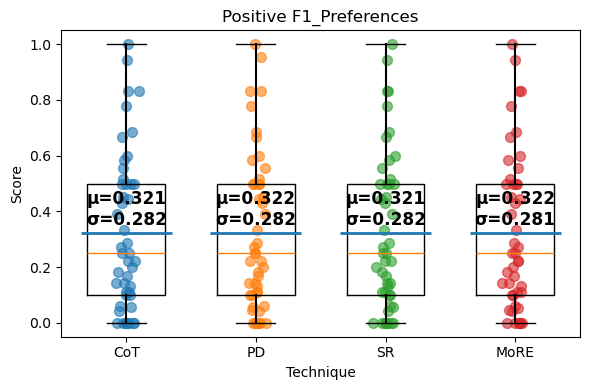

✅ Saved _temp0.0/Step4_Acc_None_Pref_plot.png


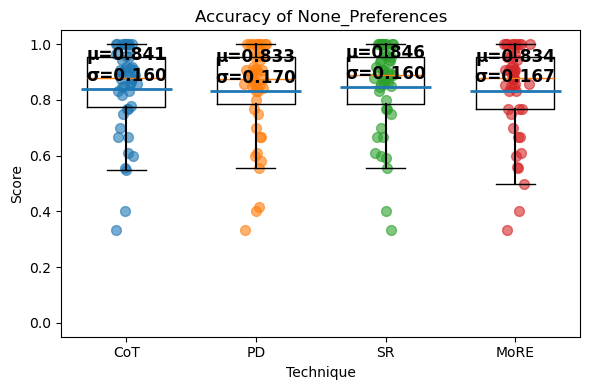

✅ Saved _temp0.0/Step4_F1_Pos_Cons_plot.png


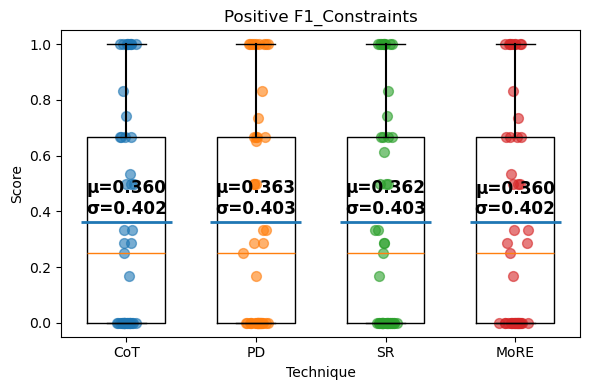

✅ Saved _temp0.0/Step4_Acc_None_Cons_plot.png


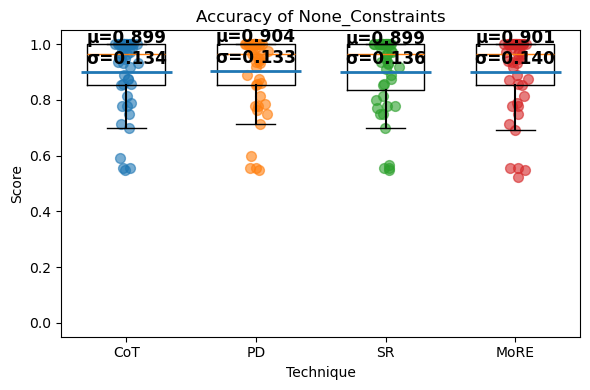

✅ Saved _temp0.0/Step4_F1_Pos_Int_plot.png


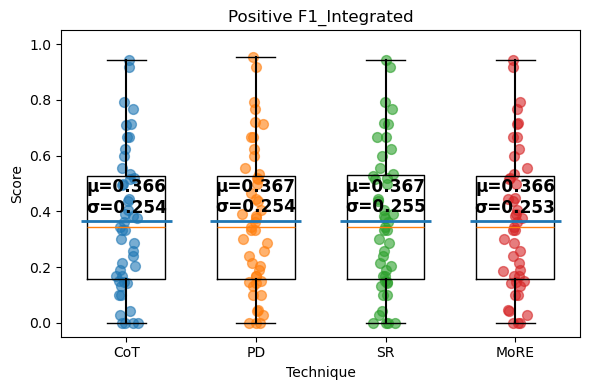

✅ Saved _temp0.0/Step4_Acc_None_Int_plot.png


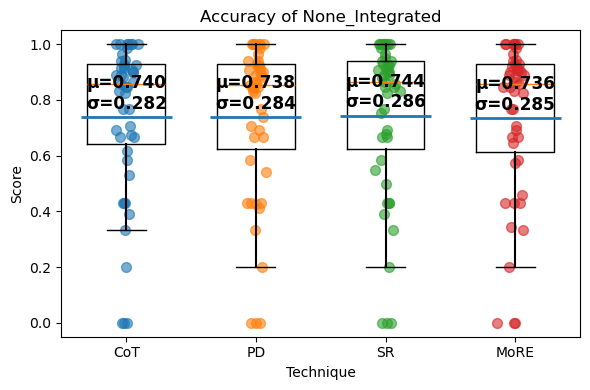

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ────────────────────────────────────────────────
# 0) Metric -> graph-title mapping  (Integrated added)
# ────────────────────────────────────────────────
title_map = {
    'F1_Pos_Pref'   : 'Positive F1_Preferences',
    'Acc_None_Pref' : 'Accuracy of None_Preferences',
    'F1_Pos_Cons'   : 'Positive F1_Constraints',
    'Acc_None_Cons' : 'Accuracy of None_Constraints',
    'F1_Pos_Int'    : 'Positive F1_Integrated',        # NEW
    'Acc_None_Int'  : 'Accuracy of None_Integrated'    # NEW
}

# ───────────────────────────────
# 1) Restore Matplotlib style to defaults
# ───────────────────────────────
plt.rcdefaults()               # reset all rcParams to defaults
plt.rcParams['font.size'] = 10 # keep the original (≈default) value

# ───────────────────────────────
# 2) Load CSV (including the integrated file)
# ───────────────────────────────
csv_files = [
    'results/gpt4o/Step4_Preferences_Score.csv',
    'results/gpt4o/Step4_Constraints_Score.csv',
    'results/gpt4o/Step4_Integrated_Score.csv'          # NEW
]

# Check existence
for f in csv_files:
    if not os.path.exists(f):
        raise FileNotFoundError(f"{f} file not found.")

# Concatenate the three files
df = pd.concat(
    [pd.read_csv(f, encoding='utf-8-sig') for f in csv_files],
    ignore_index=True
)

# Exclude 'Average' / 'Std' rows
df = df[~df['conversation_id'].isin(['Average', 'Std'])]

# ───────────────────────────────
# 3) Visualization
# ───────────────────────────────
metrics    = df['Metric'].unique().tolist()   # auto-detect all metrics
techniques = ['CoT', 'PD', 'SR', 'MoRE']      # fix the x-axis order

for metric in metrics:
    df_m = df[df['Metric'] == metric]

    plt.figure(figsize=(6, 4))

    # 3-1) jitter scatter
    for i, tech in enumerate(techniques):
        vals = df_m[tech].dropna().values
        if len(vals) == 0:
            continue
        x = np.random.normal(i, 0.04, size=len(vals))
        plt.scatter(x, vals, alpha=0.6, s=50)

    # 3-2) boxplot
    data = [df_m[tech].dropna().values for tech in techniques]
    plt.boxplot(
        data,
        positions=range(len(techniques)),
        widths=0.6,
        showfliers=False,
        showcaps=True,
        whiskerprops={'linewidth': 1.5}
    )

    # 3-3) Mean line and μ, σ
    means = [df_m[tech].mean() for tech in techniques]
    stds  = [df_m[tech].std()  for tech in techniques]
    for i, (m, s) in enumerate(zip(means, stds)):
        plt.hlines(m, i - 0.35, i + 0.35, linewidth=2)
        plt.text(
            i, m + 0.015,
            f'μ={m:.3f}\nσ={s:.3f}',
            ha='center', va='bottom',
            fontsize=12.2, weight='bold'
        )

    # 3-4) Axes and labels
    plt.ylim(-0.05, 1.05)
    plt.xticks(range(len(techniques)), techniques)
    plt.title(title_map.get(metric, metric))
    plt.xlabel('Technique')
    plt.ylabel('Score')
    plt.tight_layout()

    # 3-5) Save
    filename = f'results/gpt4o/Step4_{metric}_plot.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved {filename}")

    plt.show()
